# Hyperparameter Tuning and Model Selection for an IMDB MLP

This notebook selects checkpoints and learning rates using validation loss while keeping the held-out test split outside every training decision.

## Experiment design

The source plan refers once to a previous MNIST MLP, but the preceding classifier in this roadmap is the IMDB MLP. This experiment therefore treats that word as a continuity typo and reuses the existing IMDB model, preprocessing, split, 20,000-feature TF-IDF representation, and regularization safeguards.

The first run trains for all 100 epochs and retains the state with the lowest validation loss. A hand-written grid then compares learning rates `1e-4`, `1e-3`, `1e-2`, `1e-1`, and `1.0`. Six epochs per candidate keep the CPU search feasible, and each candidate still retains its own best validation checkpoint. Optuna tunes the same hyperparameter over a continuous log scale with the same six-epoch budget. Test labels are used only after all choices are fixed.

## Why model selection needs a validation set

Training loss rewards fit to examples already seen. Hyperparameters and checkpoint epochs chosen from that loss can overfit the training set. The validation set estimates generalization during development, while the test set remains untouched for the final report. Repeatedly choosing settings from test performance would turn the test set into another validation set.

Grid search evaluates a fixed list of settings and is simple to reproduce, but it spends equal effort on every point. Bayesian optimization uses earlier trials to propose promising settings and can search a continuous range more efficiently. Random search is another strong baseline when several hyperparameters matter.

In [1]:
from pathlib import Path
import copy
import os
import shutil
import subprocess
import sys
import time

import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd
from IPython.display import Markdown, display
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import Normalizer
import torch
from torch import nn

SEED = 42
LONG_EPOCHS = 100
SEARCH_EPOCHS = 6
OPTUNA_TRIALS = 8
BATCH_SIZE = 512
WEIGHT_DECAY = 1e-4
DROPOUT_PROBABILITY = 0.40
GRADIENT_NORM_CEILING = 1.0

np.random.seed(SEED)
torch.manual_seed(SEED)
torch.set_num_threads(min(8, os.cpu_count() or 1))
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

gpu_name = "Not detected"
if shutil.which("nvidia-smi"):
    query = subprocess.run(
        ["nvidia-smi", "--query-gpu=name", "--format=csv,noheader"],
        capture_output=True,
        text=True,
        check=True,
    )
    gpu_name = query.stdout.strip()

current_path = Path.cwd().resolve()
repository_root = next(
    (
        path
        for path in (current_path, *current_path.parents)
        if (path / "phase-1-machine-learning-nlp").is_dir()
    ),
    None,
)
if repository_root is None:
    raise FileNotFoundError("Could not locate the repository root.")

phase_1 = repository_root / "phase-1-machine-learning-nlp"
part_02 = phase_1 / "02-preprocessing-tokenization"
part_06 = phase_1 / "06-vectorization"
sys.path.insert(0, str(part_02 / "src"))
sys.path.insert(0, str(part_06 / "src"))

from preprocessor import preprocess_text
from tokenizer import regex_tokenize
from vectorizer import CustomTfidfVectorizer

imdb_path = part_02 / "data" / "IMDB Dataset.csv"
if not imdb_path.exists():
    raise FileNotFoundError(
        "Download the IMDB 50K Reviews dataset and place 'IMDB Dataset.csv' in "
        f"{imdb_path.parent}. The CSV is intentionally ignored by Git."
    )

imdb = pd.read_csv(imdb_path)
required_columns = {"review", "sentiment"}
if not required_columns.issubset(imdb.columns):
    raise KeyError(f"The IMDB dataset must contain {sorted(required_columns)}.")
imdb = imdb.dropna(subset=["review", "sentiment"])
imdb["label"] = imdb["sentiment"].map({"negative": 0, "positive": 1})
if imdb["label"].isna().any():
    raise ValueError("Sentiment labels must be either 'negative' or 'positive'.")

def model_visible_text(review):
    cleaned = preprocess_text(
        str(review), remove_stopwords=False, apply_stemming=False
    )
    return " ".join(
        token
        for token in regex_tokenize(cleaned)
        if token.isalpha() and len(token) >= 2
    )


imdb["model_visible_text"] = imdb["review"].map(model_visible_text)
if imdb["model_visible_text"].eq("").any():
    raise ValueError("Preprocessing produced an empty review.")
if imdb.groupby("model_visible_text")["label"].nunique().gt(1).any():
    raise ValueError("Reviews identical after preprocessing have conflicting labels.")
original_size = len(imdb)
imdb = imdb.drop_duplicates(subset="model_visible_text").reset_index(drop=True)

development, test = train_test_split(
    imdb,
    test_size=0.20,
    random_state=SEED,
    stratify=imdb["label"],
)
train, validation = train_test_split(
    development,
    test_size=0.25,
    random_state=SEED,
    stratify=development["label"],
)

split_frames = {"train": train, "validation": validation, "test": test}
for left, right in (("train", "validation"), ("train", "test"), ("validation", "test")):
    assert set(split_frames[left]["model_visible_text"]).isdisjoint(
        split_frames[right]["model_visible_text"]
    )

X_train, y_train = train["review"], train["label"]
X_validation, y_validation = validation["review"], validation["label"]
X_test, y_test = test["review"], test["label"]

split_summary = pd.DataFrame(
    {
        "reviews": [len(X_train), len(X_validation), len(X_test)],
        "positive proportion": [y_train.mean(), y_validation.mean(), y_test.mean()],
    },
    index=["train", "validation", "test"],
)

print(f"PyTorch: {torch.__version__}")
print(f"Optuna: {optuna.__version__}")
print(f"System GPU: {gpu_name}")
print(f"PyTorch CUDA available: {torch.cuda.is_available()}")
print(f"Selected device: {device}")
print(f"Reviews retained: {len(imdb):,} ({original_size - len(imdb):,} duplicates removed)")
print("Model-visible review overlap across splits: 0")
display(split_summary.style.format({"positive proportion": "{:.4f}"}))

PyTorch: 2.13.0+cpu
Optuna: 4.9.0
System GPU: NVIDIA GeForce RTX 3050 Ti Laptop GPU
PyTorch CUDA available: False
Selected device: cpu
Reviews retained: 49,580 (420 duplicates removed)
Model-visible review overlap across splits: 0


,reviews,positive proportion
train,29748,0.5019
validation,9916,0.5019
test,9916,0.5019


In [2]:
vectorizer = CustomTfidfVectorizer(
    preprocessor=preprocess_text,
    tokenizer=regex_tokenize,
    min_df=5,
    max_df=0.95,
    max_features=20_000,
)
input_normalizer = Normalizer(norm="l2", copy=False)

vectorization_start = time.perf_counter()
X_train_tfidf = input_normalizer.fit_transform(
    vectorizer.fit_transform(X_train)
).astype(np.float32)
X_validation_tfidf = input_normalizer.transform(
    vectorizer.transform(X_validation)
).astype(np.float32)
X_test_tfidf = input_normalizer.transform(
    vectorizer.transform(X_test)
).astype(np.float32)
vectorization_seconds = time.perf_counter() - vectorization_start

y_train_array = y_train.to_numpy(dtype=np.float32)
y_validation_array = y_validation.to_numpy(dtype=np.float32)
y_test_array = y_test.to_numpy(dtype=np.float32)
train_norms = np.sqrt(X_train_tfidf.multiply(X_train_tfidf).sum(axis=1)).A1
nonzero_norms = train_norms[train_norms > 0]
density = X_train_tfidf.nnz / np.prod(X_train_tfidf.shape)

print(f"Vocabulary size: {len(vectorizer.vocabulary_):,}")
print(f"Training matrix shape: {X_train_tfidf.shape}")
print(f"Training matrix density: {density:.4%}")
print(f"Mean non-empty training-row L2 norm: {nonzero_norms.mean():.6f}")
print(f"Vectorization time: {vectorization_seconds:.2f} seconds")
assert np.allclose(nonzero_norms, 1.0, atol=1e-5)

Vocabulary size: 20,000
Training matrix shape: (29748, 20000)
Training matrix density: 0.6252%
Mean non-empty training-row L2 norm: 1.000000
Vectorization time: 17.23 seconds


## Checkpointed training

Every run starts from the same initialized weights and sees the same per-epoch shuffle, isolating learning rate as the tuned variable. Dropout, AdamW weight decay, gradient clipping, batch normalization, and the stable fused binary loss match the preceding regularized MLP. Checkpoints live only in memory; no large model artifact is written to the repository.

In [3]:
class RegularizedSentimentMLP(nn.Module):
    def __init__(self, input_features, dropout_probability):
        super().__init__()
        self.hidden_1 = nn.Linear(input_features, 128)
        self.normalization_1 = nn.BatchNorm1d(128)
        self.dropout_1 = nn.Dropout(dropout_probability)
        self.hidden_2 = nn.Linear(128, 64)
        self.normalization_2 = nn.BatchNorm1d(64)
        self.dropout_2 = nn.Dropout(dropout_probability)
        self.output = nn.Linear(64, 1)
        nn.init.kaiming_normal_(self.hidden_1.weight, nonlinearity="relu")
        nn.init.zeros_(self.hidden_1.bias)
        nn.init.kaiming_normal_(self.hidden_2.weight, nonlinearity="relu")
        nn.init.zeros_(self.hidden_2.bias)
        nn.init.xavier_uniform_(self.output.weight)
        nn.init.zeros_(self.output.bias)

    def forward(self, features):
        if features.is_sparse:
            hidden = torch.sparse.mm(features, self.hidden_1.weight.T)
            hidden = hidden + self.hidden_1.bias
        else:
            hidden = self.hidden_1(features)
        hidden = self.dropout_1(torch.relu(self.normalization_1(hidden)))
        hidden = self.dropout_2(
            torch.relu(self.normalization_2(self.hidden_2(hidden)))
        )
        return self.output(hidden).squeeze(1)


loss_function = nn.BCEWithLogitsLoss()

def reset_seed():
    np.random.seed(SEED)
    torch.manual_seed(SEED)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(SEED)


def to_sparse_batch(matrix, indices):
    batch = matrix[indices].tocoo()
    coordinates = np.vstack((batch.row, batch.col)).astype(np.int64)
    return torch.sparse_coo_tensor(
        torch.from_numpy(coordinates),
        torch.from_numpy(batch.data),
        size=batch.shape,
        device=device,
        check_invariants=False,
    ).coalesce()


def evaluate_model(model, matrix, labels):
    model.eval()
    total_loss = 0.0
    probabilities = []
    with torch.no_grad():
        for start in range(0, len(labels), BATCH_SIZE):
            indices = np.arange(start, min(start + BATCH_SIZE, len(labels)))
            features = to_sparse_batch(matrix, indices)
            targets = torch.from_numpy(labels[indices]).to(device)
            logits = model(features)
            loss = loss_function(logits, targets)
            if not torch.isfinite(loss):
                raise FloatingPointError("Evaluation produced a non-finite loss.")
            total_loss += loss.item() * len(indices)
            probabilities.append(torch.sigmoid(logits).cpu().numpy())
    return total_loss / len(labels), np.concatenate(probabilities)


def state_on_cpu(model):
    return {
        name: value.detach().cpu().clone()
        for name, value in model.state_dict().items()
    }


def model_from_state(state):
    model = RegularizedSentimentMLP(
        X_train_tfidf.shape[1], DROPOUT_PROBABILITY
    ).to(device)
    model.load_state_dict(state)
    return model


def train_and_select(learning_rate, epochs, label, verbose=False):
    reset_seed()
    model = RegularizedSentimentMLP(
        X_train_tfidf.shape[1], DROPOUT_PROBABILITY
    ).to(device)
    decay_parameters = []
    no_decay_parameters = []
    for parameter in model.parameters():
        if parameter.ndim > 1:
            decay_parameters.append(parameter)
        else:
            no_decay_parameters.append(parameter)
    optimizer = torch.optim.AdamW(
        [
            {"params": decay_parameters, "weight_decay": WEIGHT_DECAY},
            {"params": no_decay_parameters, "weight_decay": 0.0},
        ],
        lr=learning_rate,
    )
    history = []
    best_state = None
    best_validation_loss = float("inf")
    best_epoch = None
    start_time = time.perf_counter()

    for epoch in range(1, epochs + 1):
        model.train()
        total_training_loss = 0.0
        shuffled_indices = np.random.default_rng(SEED + epoch).permutation(
            len(y_train_array)
        )
        for start in range(0, len(y_train_array), BATCH_SIZE):
            indices = shuffled_indices[start:start + BATCH_SIZE]
            features = to_sparse_batch(X_train_tfidf, indices)
            targets = torch.from_numpy(y_train_array[indices]).to(device)
            optimizer.zero_grad()
            logits = model(features)
            loss = loss_function(logits, targets)
            if not torch.isfinite(loss):
                raise FloatingPointError(
                    f"{label} produced a non-finite training loss at epoch {epoch}."
                )
            loss.backward()
            torch.nn.utils.clip_grad_norm_(
                model.parameters(),
                GRADIENT_NORM_CEILING,
                error_if_nonfinite=True,
            )
            optimizer.step()
            total_training_loss += loss.item() * len(indices)

        training_loss = total_training_loss / len(y_train_array)
        validation_loss, validation_probabilities = evaluate_model(
            model, X_validation_tfidf, y_validation_array
        )
        validation_predictions = (validation_probabilities >= 0.5).astype(int)
        row = {
            "epoch": epoch,
            "train loss": training_loss,
            "validation loss": validation_loss,
            "validation accuracy": accuracy_score(
                y_validation_array, validation_predictions
            ),
            "validation F1": f1_score(
                y_validation_array, validation_predictions
            ),
        }
        history.append(row)
        if validation_loss < best_validation_loss:
            best_validation_loss = validation_loss
            best_epoch = epoch
            best_state = state_on_cpu(model)
        if verbose and (epoch == 1 or epoch % 10 == 0 or epoch == epochs):
            print(
                f"{label} | epoch {epoch:>3}/{epochs} | "
                f"train loss {training_loss:.4f} | "
                f"validation loss {validation_loss:.4f} | "
                f"validation accuracy {row['validation accuracy']:.4f}"
            )

    history_frame = pd.DataFrame(history).set_index("epoch")
    best_row = history_frame.loc[best_epoch]
    summary = {
        "learning rate": learning_rate,
        "epochs trained": epochs,
        "best epoch": best_epoch,
        "validation loss": best_validation_loss,
        "validation accuracy": best_row["validation accuracy"],
        "validation F1": best_row["validation F1"],
        "seconds": time.perf_counter() - start_time,
    }
    del model
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    return best_state, history_frame, summary

## One hundred epochs with validation checkpointing

Training continues for the full requested budget even after the validation score stops improving. The retained state is the epoch with minimum validation loss, not the final state.

100-epoch run | epoch   1/100 | train loss 0.3978 | validation loss 0.3413 | validation accuracy 0.8942


100-epoch run | epoch  10/100 | train loss 0.0033 | validation loss 0.5596 | validation accuracy 0.8723


100-epoch run | epoch  20/100 | train loss 0.0060 | validation loss 0.7166 | validation accuracy 0.8715


100-epoch run | epoch  30/100 | train loss 0.0040 | validation loss 0.8017 | validation accuracy 0.8694


100-epoch run | epoch  40/100 | train loss 0.0027 | validation loss 0.8661 | validation accuracy 0.8710


...

100-epoch run | epoch  70/100 | train loss 0.0015 | validation loss 1.0120 | validation accuracy 0.8677


100-epoch run | epoch  80/100 | train loss 0.0027 | validation loss 0.9874 | validation accuracy 0.8682


100-epoch run | epoch  90/100 | train loss 0.0018 | validation loss 0.9795 | validation accuracy 0.8698


100-epoch run | epoch 100/100 | train loss 0.0014 | validation loss 1.0094 | validation accuracy 0.8708


,learning rate,epochs trained,best epoch,validation loss,validation accuracy,validation F1,seconds
100-epoch run,1.0e-03,100,2,0.2720,0.8916,0.8930,487.72


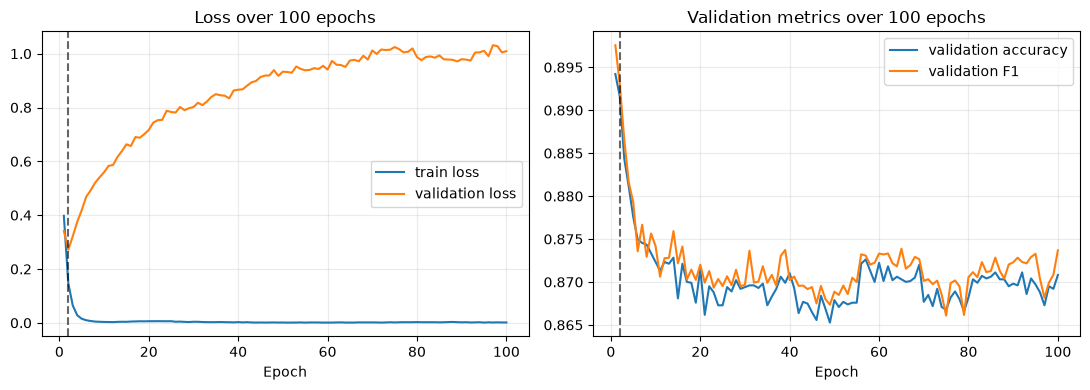

In [4]:
long_state, long_history, long_summary = train_and_select(
    learning_rate=1e-3,
    epochs=LONG_EPOCHS,
    label="100-epoch run",
    verbose=True,
)

display(pd.DataFrame([long_summary], index=["100-epoch run"]).style.format({
    "learning rate": "{:.1e}",
    "validation loss": "{:.4f}",
    "validation accuracy": "{:.4f}",
    "validation F1": "{:.4f}",
    "seconds": "{:.2f}",
}))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
long_history[["train loss", "validation loss"]].plot(ax=axes[0])
long_history[["validation accuracy", "validation F1"]].plot(ax=axes[1])
axes[0].axvline(long_summary["best epoch"], color="black", linestyle="--", alpha=0.6)
axes[1].axvline(long_summary["best epoch"], color="black", linestyle="--", alpha=0.6)
axes[0].set_title("Loss over 100 epochs")
axes[1].set_title("Validation metrics over 100 epochs")
for axis in axes:
    axis.grid(alpha=0.25)
    axis.set_xlabel("Epoch")
plt.tight_layout()
plt.show()

## Manual learning-rate grid

The loop below is the complete tuning implementation: it trains every candidate independently, records the best checkpoint within that run, and selects the learning rate with the lowest validation loss. Neither Optuna nor the test set participates.

manual lr=0.0001 | best epoch 6 | validation loss 0.2667 | validation accuracy 0.8898


manual lr=0.001 | best epoch 2 | validation loss 0.2720 | validation accuracy 0.8916


manual lr=0.01 | best epoch 1 | validation loss 0.2611 | validation accuracy 0.8933


manual lr=0.1 | best epoch 1 | validation loss 0.2766 | validation accuracy 0.8842


manual lr=1 | best epoch 2 | validation loss 0.3250 | validation accuracy 0.8661


,learning rate,epochs trained,best epoch,validation loss,validation accuracy,validation F1,seconds,status
0,1.0e-04,6,6,0.2667,0.8898,0.8897,29.00,completed
1,1.0e-03,6,2,0.2720,0.8916,0.8930,29.08,completed
2,1.0e-02,6,1,0.2611,0.8933,0.8936,28.67,completed
3,1.0e-01,6,1,0.2766,0.8842,0.8874,29.27,completed
4,1.0e+00,6,2,0.3250,0.8661,0.8686,29.61,completed


Selected manual learning rate: 1.0e-02


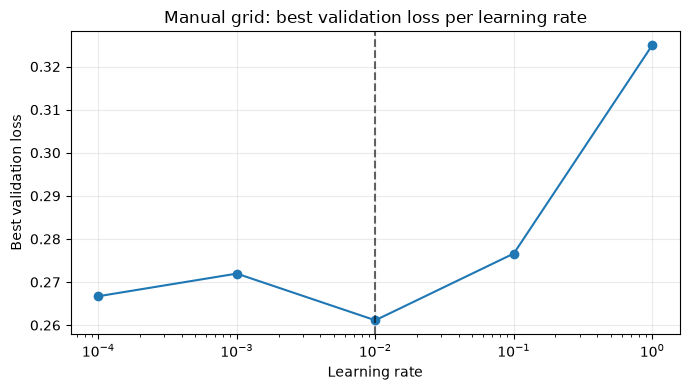

In [5]:
learning_rate_grid = [1e-4, 1e-3, 1e-2, 1e-1, 1.0]
manual_states = {}
manual_histories = {}
manual_summaries = []

for learning_rate in learning_rate_grid:
    label = f"manual lr={learning_rate:g}"
    try:
        state, history, summary = train_and_select(
            learning_rate=learning_rate,
            epochs=SEARCH_EPOCHS,
            label=label,
        )
        summary["status"] = "completed"
        manual_states[learning_rate] = state
        manual_histories[learning_rate] = history
        manual_summaries.append(summary)
        print(
            f"{label} | best epoch {summary['best epoch']} | "
            f"validation loss {summary['validation loss']:.4f} | "
            f"validation accuracy {summary['validation accuracy']:.4f}"
        )
    except FloatingPointError as error:
        manual_summaries.append(
            {
                "learning rate": learning_rate,
                "epochs trained": SEARCH_EPOCHS,
                "best epoch": np.nan,
                "validation loss": np.inf,
                "validation accuracy": np.nan,
                "validation F1": np.nan,
                "seconds": np.nan,
                "status": str(error),
            }
        )
        print(f"{label} | stopped: {error}")

manual_results = pd.DataFrame(manual_summaries).sort_values("learning rate")
valid_manual_results = manual_results[np.isfinite(manual_results["validation loss"])]
manual_best_row = valid_manual_results.loc[
    valid_manual_results["validation loss"].idxmin()
]
manual_best_learning_rate = float(manual_best_row["learning rate"])
manual_best_state = manual_states[manual_best_learning_rate]

display(manual_results.style.format({
    "learning rate": "{:.1e}",
    "validation loss": "{:.4f}",
    "validation accuracy": "{:.4f}",
    "validation F1": "{:.4f}",
    "seconds": "{:.2f}",
}))
print(f"Selected manual learning rate: {manual_best_learning_rate:.1e}")

plt.figure(figsize=(7, 4))
plt.semilogx(
    valid_manual_results["learning rate"],
    valid_manual_results["validation loss"],
    marker="o",
)
plt.axvline(manual_best_learning_rate, color="black", linestyle="--", alpha=0.6)
plt.title("Manual grid: best validation loss per learning rate")
plt.xlabel("Learning rate")
plt.ylabel("Best validation loss")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## Optuna learning-rate tuning

Optuna uses a seeded TPE sampler to propose eight learning rates on a continuous log scale from `1e-5` to `1e-1`. Three startup trials establish an initial sample before TPE uses those results to guide later proposals. The objective remains best validation loss, and each trial has the same six-epoch budget as a manual-grid candidate.

,trial,learning rate,best epoch,validation loss,validation accuracy,validation F1,seconds
7,7,3.880e-04,2,0.2569,0.8934,0.8948,29.21
0,0,3.149e-04,3,0.2597,0.8934,0.8955,29.09
2,2,8.472e-03,1,0.2616,0.8912,0.8916,29.52
4,4,1.546e-04,5,0.2622,0.8906,0.8919,28.96
5,5,9.760e-04,2,0.2711,0.8914,0.8927,29.00
1,1,6.351e-02,1,0.2718,0.8888,0.8894,29.01
3,3,1.392e-05,6,0.5157,0.7640,0.7473,29.33
6,6,1.180e-05,6,0.5408,0.7405,0.7166,29.07


Selected Optuna learning rate: 3.880e-04 from trial 7


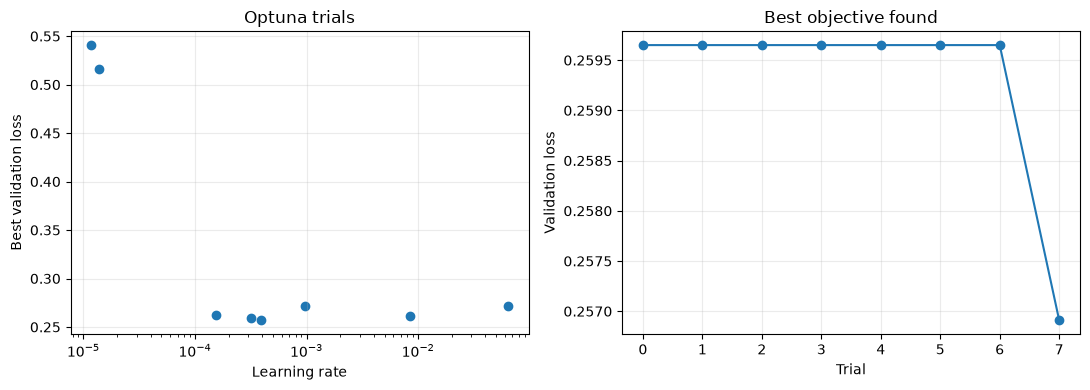

In [6]:
optuna.logging.set_verbosity(optuna.logging.WARNING)
optuna_states = {}
optuna_histories = {}
optuna_summaries = {}

def objective(trial):
    learning_rate = trial.suggest_float(
        "learning_rate", 1e-5, 1e-1, log=True
    )
    state, history, summary = train_and_select(
        learning_rate=learning_rate,
        epochs=SEARCH_EPOCHS,
        label=f"Optuna trial {trial.number}",
    )
    optuna_states[trial.number] = state
    optuna_histories[trial.number] = history
    optuna_summaries[trial.number] = summary
    trial.set_user_attr("best_epoch", int(summary["best epoch"]))
    trial.set_user_attr(
        "validation_accuracy", float(summary["validation accuracy"])
    )
    return summary["validation loss"]


study = optuna.create_study(
    direction="minimize",
    sampler=optuna.samplers.TPESampler(seed=SEED, n_startup_trials=3),
)
study.optimize(objective, n_trials=OPTUNA_TRIALS)

optuna_rows = []
for trial in study.trials:
    summary = optuna_summaries[trial.number]
    optuna_rows.append(
        {
            "trial": trial.number,
            "learning rate": trial.params["learning_rate"],
            "best epoch": summary["best epoch"],
            "validation loss": summary["validation loss"],
            "validation accuracy": summary["validation accuracy"],
            "validation F1": summary["validation F1"],
            "seconds": summary["seconds"],
        }
    )
optuna_results = pd.DataFrame(optuna_rows).sort_values("validation loss")
optuna_best_trial_number = study.best_trial.number
optuna_best_state = optuna_states[optuna_best_trial_number]
optuna_best_summary = optuna_summaries[optuna_best_trial_number]

display(optuna_results.style.format({
    "learning rate": "{:.3e}",
    "validation loss": "{:.4f}",
    "validation accuracy": "{:.4f}",
    "validation F1": "{:.4f}",
    "seconds": "{:.2f}",
}))
print(
    f"Selected Optuna learning rate: {study.best_params['learning_rate']:.3e} "
    f"from trial {optuna_best_trial_number}"
)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].scatter(
    optuna_results["learning rate"],
    optuna_results["validation loss"],
)
axes[0].set_xscale("log")
axes[0].set_title("Optuna trials")
axes[0].set_xlabel("Learning rate")
axes[0].set_ylabel("Best validation loss")
study.trials_dataframe()["value"].cummin().plot(ax=axes[1], marker="o")
axes[1].set_title("Best objective found")
axes[1].set_xlabel("Trial")
axes[1].set_ylabel("Validation loss")
for axis in axes:
    axis.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## Held-out evaluation

The three retained checkpoints are now fixed from validation results. Their test metrics are reported only after selection, and the declared final model is the candidate with the lowest validation loss.

,validation loss,test loss,test accuracy,test precision,test recall,test F1,test ROC AUC
candidate,,,,,,,
100-epoch checkpoint,0.2720,0.2794,0.8872,0.8791,0.8987,0.8888,0.9568
manual-grid winner,0.2611,0.2637,0.8893,0.8909,0.8881,0.8895,0.9577
Optuna winner,0.2569,0.2599,0.8920,0.8870,0.8993,0.8931,0.9591


Final model selected before test evaluation: Optuna winner
              precision    recall  f1-score   support

    negative     0.8971    0.8846    0.8908      4939
    positive     0.8870    0.8993    0.8931      4977

    accuracy                         0.8920      9916
   macro avg     0.8921    0.8920    0.8920      9916
weighted avg     0.8921    0.8920    0.8920      9916



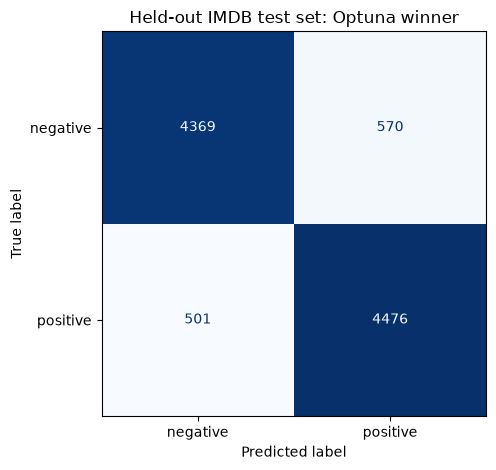

In [7]:
candidate_states = {
    "100-epoch checkpoint": long_state,
    "manual-grid winner": manual_best_state,
    "Optuna winner": optuna_best_state,
}
candidate_validation_losses = {
    "100-epoch checkpoint": long_summary["validation loss"],
    "manual-grid winner": float(manual_best_row["validation loss"]),
    "Optuna winner": optuna_best_summary["validation loss"],
}
final_candidate = min(
    candidate_validation_losses, key=candidate_validation_losses.get
)
test_rows = []
final_predictions = None

for candidate, state in candidate_states.items():
    model = model_from_state(state)
    test_loss, test_probabilities = evaluate_model(
        model, X_test_tfidf, y_test_array
    )
    test_predictions = (test_probabilities >= 0.5).astype(int)
    test_rows.append(
        {
            "candidate": candidate,
            "validation loss": candidate_validation_losses[candidate],
            "test loss": test_loss,
            "test accuracy": accuracy_score(y_test_array, test_predictions),
            "test precision": precision_score(y_test_array, test_predictions),
            "test recall": recall_score(y_test_array, test_predictions),
            "test F1": f1_score(y_test_array, test_predictions),
            "test ROC AUC": roc_auc_score(y_test_array, test_probabilities),
        }
    )
    if candidate == final_candidate:
        final_predictions = test_predictions
    del model

test_results = pd.DataFrame(test_rows).set_index("candidate")
display(test_results.style.format("{:.4f}"))
print(f"Final model selected before test evaluation: {final_candidate}")
print(classification_report(
    y_test_array,
    final_predictions,
    target_names=["negative", "positive"],
    digits=4,
))

ConfusionMatrixDisplay.from_predictions(
    y_test_array,
    final_predictions,
    display_labels=["negative", "positive"],
    cmap="Blues",
    colorbar=False,
)
plt.title(f"Held-out IMDB test set: {final_candidate}")
plt.tight_layout()
plt.show()

assert np.isfinite(test_results.to_numpy()).all()
assert len(final_predictions) == len(y_test_array)

In [8]:
final_metrics = test_results.loc[final_candidate]
manual_lr = manual_best_learning_rate
optuna_lr = study.best_params["learning_rate"]
long_final_validation_loss = long_history.iloc[-1]["validation loss"]
long_best_validation_loss = long_summary["validation loss"]
display(Markdown(
    f'''## Observations

The 100-epoch run selected epoch **{long_summary['best epoch']}** with validation loss **{long_best_validation_loss:.4f}**, while the final epoch reached **{long_final_validation_loss:.4f}**. Continuing to train therefore did not justify selecting the last checkpoint.

The manual grid selected learning rate **{manual_lr:.1e}** at epoch **{int(manual_best_row['best epoch'])}**. Optuna selected **{optuna_lr:.3e}** at epoch **{optuna_best_summary['best epoch']}**. The overall validation rule selected the **{final_candidate}** before any test comparison.

That checkpoint achieved held-out test accuracy **{final_metrics['test accuracy']:.4f}**, F1 **{final_metrics['test F1']:.4f}**, and ROC AUC **{final_metrics['test ROC AUC']:.4f}**. The search results also show that an excessively large learning rate can be numerically finite yet generalize poorly, so finite gradients alone are not evidence of a useful optimizer setting.

The detected system GPU was **{gpu_name}**, but this PyTorch build exposed CUDA as **{torch.cuda.is_available()}**. The experiment therefore used **{device}** and kept the tuning budgets small enough for reproducible local execution.'''
))

## Observations

The 100-epoch run selected epoch **2** with validation loss **0.2720**, while the final epoch reached **1.0094**. Continuing to train therefore did not justify selecting the last checkpoint.

The manual grid selected learning rate **1.0e-02** at epoch **1**. Optuna selected **3.880e-04** at epoch **2**. The overall validation rule selected the **Optuna winner** before any test comparison.

That checkpoint achieved held-out test accuracy **0.8920**, F1 **0.8931**, and ROC AUC **0.9591**. The search results also show that an excessively large learning rate can be numerically finite yet generalize poorly, so finite gradients alone are not evidence of a useful optimizer setting.

The detected system GPU was **NVIDIA GeForce RTX 3050 Ti Laptop GPU**, but this PyTorch build exposed CUDA as **False**. The experiment therefore used **cpu** and kept the tuning budgets small enough for reproducible local execution.